# Predicción de patrones de resistencia (LPS) a partir de espectros MALDI-TOF

En este cuaderno se entrena un modelo **MLP específico por especie** para predecir patrones de resistencia antimicrobiana (LPS, *Label Powerset*) a partir de espectros MALDI-TOF.

## Objetivo
Para cada especie:

1. Seleccionar el subconjunto de antibióticos correspondiente.
2. Integrar datos de **DRIAMS** y **MARISMA**.
3. Aplicar el mismo pipeline de preprocesado:
   - alineado de antibióticos entre datasets,
   - concatenación,
   - eliminación de muestras con valores ausentes,
   - construcción de patrones de resistencia,
   - filtrado de patrones raros.
4. Dividir en **train / validation / test** con estratificación por patrón.
5. Entrenar un **MLP LPS** con los hiperparámetros predefinidos.
6. Extraer los **embeddings de la última capa oculta**.
7. Visualizar esos embeddings con **t-SNE**.
8. Evaluar el modelo mediante:
   - accuracy en patrones LPS,
   - macro-F1 en patrones LPS,
   - matriz de confusión clínica colapsando a:
     - **S**: ninguna resistencia,
     - **UR**: una única resistencia,
     - **MR**: múltiples resistencias.

## Nota metodológica
En este enfoque LPS, cada patrón binario de resistencia se trata como una clase única.  
Posteriormente, para facilitar la interpretación clínica, las predicciones se agrupan también en tres categorías: susceptible, resistencia única y resistencia múltiple.

### Imports and configuration

In [1]:
import os
import copy
import pickle
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.manifold import TSNE

SEED = 42
TEST_SIZE = 0.20
VAL_SIZE_WITHIN_TRAIN = 0.20
MAX_EPOCHS = 1500
PATIENCE = 50
BATCH_SIZE = 128
MIN_PATTERN_COUNT = 10  

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
driams_path = "/export/usuarios01/egarroyo/MALDI_for_AMR_prediction/data/DRIAMS_A_AMR_whole_pipeline_23_DRIAMS.pkl"
marisma_path = "/export/usuarios01/egarroyo/MALDI_for_AMR_prediction/data/MARISMa_study_MARISMA_whole_pipeline.pkl"

with open(driams_path, "rb") as f:
    driams_payload = pickle.load(f)

with open(marisma_path, "rb") as f:
    marisma_payload = pickle.load(f)

print("Datasets loaded.")

Datasets loaded.


In [3]:
species_antibiotics = {
    "Staphylococcus_Aureus": [
        "Oxacillin", "Clindamycin", "Fusidic acid"
    ],
    "Escherichia_Coli": [
        "Ciprofloxacin", "Ceftriaxone", "Cefepime"
    ],
    "Klebsiella_Pneumoniae": [
        "Ciprofloxacin", "Imipenem", "Meropenem"
    ],
    "Pseudomonas_Aeruginosa": [
        "Ciprofloxacin", "Imipenem", "Meropenem"
    ]
}

mlp_lps_params = {
    "Escherichia_Coli": dict(
        hidden_layer_sizes=(481, 24, 500),
        activation="relu",
        solver="adam",
        learning_rate_init=2.4378878006413237e-05
    ),
    "Klebsiella_Pneumoniae": dict(
        hidden_layer_sizes=(94, 313, 99),
        activation="tanh",
        solver="adam",
        learning_rate_init=7.693489492906515e-05
    ),
    "Pseudomonas_Aeruginosa": dict(
        hidden_layer_sizes=(402, 208, 435),
        activation="relu",
        solver="adam",
        learning_rate_init=0.004215968282365892
    ),
    "Staphylococcus_Aureus": dict(
        hidden_layer_sizes=(289, 242, 189),
        activation="identity",
        solver="adam",
        learning_rate_init=0.0008078817205716293
    ),
}

## 2. Inspección inicial de los datasets

Se muestra la estructura general de cada dataset para comprobar la forma de los espectros, la matriz AMR y las especies disponibles.

In [4]:
def inspect_dataset(payload, name):
    X = payload["data"]
    y_species = payload["label"]
    amr = payload["amr"]
    antibiotics = payload["antibiotics"]

    print(f"\n{name}")
    print("-" * 50)
    print("Spectra shape:", X.shape)
    print("AMR matrix shape:", amr.shape)
    print("Number of antibiotics:", len(antibiotics))
    print("Unique species:", np.unique(y_species))

inspect_dataset(driams_payload, "DRIAMS")
inspect_dataset(marisma_payload, "MARISMA")


DRIAMS
--------------------------------------------------
Spectra shape: (18168, 6000)
AMR matrix shape: (18168, 9)
Number of antibiotics: 9
Unique species: ['Escherichia_Coli' 'Klebsiella_Pneumoniae' 'Pseudomonas_Aeruginosa'
 'Staphylococcus_Aureus']

MARISMA
--------------------------------------------------
Spectra shape: (21360, 6000)
AMR matrix shape: (21360, 8)
Number of antibiotics: 8
Unique species: ['Escherichia_Coli' 'Klebsiella_Pneumoniae' 'Pseudomonas_Aeruginosa'
 'Staphylococcus_Aureus']


## 3. Funciones auxiliares de preprocesado

Las siguientes funciones implementan el pipeline de preprocesado:

- extracción por especie,
- alineado de antibióticos entre datasets,
- eliminación de muestras con valores ausentes,
- construcción de patrones de resistencia,
- filtrado de patrones raros,
- colapso de patrones a categorías clínicas:
  - S (sin resistencias),
  - UR (resistencia única),
  - MR (resistencia múltiple).

In [5]:
def extract_species_dataset(payload, species, antibiotics_subset):
    X = payload["data"]
    y = payload["label"]
    amr = payload["amr"]
    antibiotics = payload["antibiotics"]

    mask_species = y == species
    X_species = X[mask_species]
    amr_species = amr[mask_species]

    available_ab = [ab for ab in antibiotics_subset if ab in antibiotics]

    if len(available_ab) == 0:
        return None, None, []

    ab_idx = [antibiotics.index(ab) for ab in available_ab]
    amr_species = amr_species[:, ab_idx]

    return X_species, amr_species, available_ab


def align_matrix(payload, species, antibiotics_final):
    X = payload["data"]
    y = payload["label"]
    amr = payload["amr"]
    antibiotics = payload["antibiotics"]

    mask = y == species
    X_species = X[mask]
    amr_species = amr[mask]

    Y = np.full((amr_species.shape[0], len(antibiotics_final)), np.nan)

    for j, ab in enumerate(antibiotics_final):
        if ab in antibiotics:
            idx = antibiotics.index(ab)
            Y[:, j] = amr_species[:, idx]

    return X_species, Y


def remove_missing(X, y):
    mask_valid = ~np.isnan(X).any(axis=1) & ~np.isnan(y).any(axis=1)
    return X[mask_valid], y[mask_valid]


def compute_lps_patterns(y):
    patterns = ["".join(map(str, row.astype(int))) for row in y]
    return np.array(patterns)


def filter_rare_patterns(X, y, min_samples=10):
    patterns = compute_lps_patterns(y)
    counts = Counter(patterns)
    valid_patterns = {p for p, c in counts.items() if c >= min_samples}
    mask = np.array([p in valid_patterns for p in patterns])
    return X[mask], y[mask], patterns[mask]


def pattern_to_clinical_group(pattern_str):
    n_res = pattern_str.count("1")
    if n_res == 0:
        return "S"
    elif n_res == 1:
        return "UR"
    else:
        return "MR"

## 4. Construcción de los datasets finales por especie

Para cada especie:

1. Se identifican los antibióticos disponibles en DRIAMS y MARISMA.
2. Se crea la unión de antibióticos.
3. Se alinean ambas matrices AMR a ese conjunto común.
4. Se concatenan ambos datasets.
5. Se eliminan muestras con datos ausentes.
6. Se construyen patrones LPS.
7. Se filtran patrones poco frecuentes.

El resultado es un dataset curado por especie listo para entrenar.

In [6]:
species_datasets = {}

for species, ab_list in species_antibiotics.items():
    print(f"\nProcessing: {species}")

    X_d_tmp, y_d_tmp, ab_d = extract_species_dataset(driams_payload, species, ab_list)
    X_m_tmp, y_m_tmp, ab_m = extract_species_dataset(marisma_payload, species, ab_list)

    if X_d_tmp is None and X_m_tmp is None:
        print("  No antibiotics available.")
        continue

    final_antibiotics = sorted(list(set(ab_d).union(set(ab_m))))
    print("  Final antibiotics:", final_antibiotics)

    X_d, y_d = align_matrix(driams_payload, species, final_antibiotics)
    X_m, y_m = align_matrix(marisma_payload, species, final_antibiotics)

    X = np.vstack([X_d, X_m])
    y = np.vstack([y_d, y_m])

    origin_raw = np.array(["DRIAMS"] * X_d.shape[0] + ["MARISMA"] * X_m.shape[0])

    X_raw = X.copy()
    y_raw = y.copy()

    X, y = remove_missing(X, y)
    X, y, patterns = filter_rare_patterns(X, y, min_samples=MIN_PATTERN_COUNT)

    species_datasets[species] = {
        "X": X,
        "y": y,
        "patterns": patterns,
        "antibiotics": final_antibiotics,
        "X_raw": X_raw,
        "y_raw": y_raw,
        "origin_raw": origin_raw
    }

print("\nDone.")


Processing: Staphylococcus_Aureus
  Final antibiotics: ['Clindamycin', 'Fusidic acid', 'Oxacillin']

Processing: Escherichia_Coli
  Final antibiotics: ['Cefepime', 'Ceftriaxone', 'Ciprofloxacin']

Processing: Klebsiella_Pneumoniae
  Final antibiotics: ['Ciprofloxacin', 'Imipenem', 'Meropenem']

Processing: Pseudomonas_Aeruginosa
  Final antibiotics: ['Ciprofloxacin', 'Imipenem', 'Meropenem']

Done.


In [7]:
rows = []

for species, dataset in species_datasets.items():
    rows.append({
        "species": species,
        "samples": dataset["X"].shape[0],
        "spectral_features": dataset["X"].shape[1],
        "antibiotics": len(dataset["antibiotics"]),
        "n_patterns": len(np.unique(dataset["patterns"]))
    })

species_stats = pd.DataFrame(rows).sort_values("samples", ascending=False)
species_stats

,species,samples,spectral_features,antibiotics,n_patterns
2,Klebsiella_Pneumoniae,18386,6000,3,7
1,Escherichia_Coli,5616,6000,3,7
0,Staphylococcus_Aureus,4649,6000,3,8
3,Pseudomonas_Aeruginosa,3843,6000,3,6


In [8]:
pattern_tables = {}

for species, dataset in species_datasets.items():
    pattern_counts = Counter(dataset["patterns"])
    df = pd.DataFrame({
        "pattern": list(pattern_counts.keys()),
        "count": list(pattern_counts.values())
    }).sort_values("count", ascending=False)
    df["frequency"] = df["count"] / df["count"].sum()
    pattern_tables[species] = df

    print("\n" + "="*70)
    print(species)
    print("="*70)
    display(df)


Staphylococcus_Aureus


,pattern,count,frequency
0,000,3260,0.701226
6,001,457,0.098301
2,100,378,0.081308
1,101,211,0.045386
3,010,166,0.035707
4,011,99,0.021295
7,110,48,0.010325
5,111,30,0.006453



Escherichia_Coli


,pattern,count,frequency
1,000,3723,0.662927
2,111,722,0.128561
0,001,701,0.124822
3,110,229,0.040776
6,011,143,0.025463
4,010,76,0.013533
5,101,22,0.003917



Klebsiella_Pneumoniae


,pattern,count,frequency
0,000,13592,0.739258
1,100,4186,0.227673
3,111,359,0.019526
6,110,119,0.006472
4,101,54,0.002937
2,011,38,0.002067
5,010,38,0.002067



Pseudomonas_Aeruginosa


,pattern,count,frequency
0,000,1918,0.499089
2,110,818,0.212855
3,010,440,0.114494
5,111,331,0.086131
1,100,171,0.044496
4,011,165,0.042935


## 7. Definición del modelo MLP-LPS

Se implementa un MLP en PyTorch con:

- número de capas ocultas configurable,
- activación configurable (`relu`, `tanh`, `identity`),
- capa de salida para clasificación multiclase de patrones,
- método para extraer los **embeddings de la última capa oculta**.

In [9]:
def get_activation(name):
    if name == "relu":
        return nn.ReLU()
    elif name == "tanh":
        return nn.Tanh()
    elif name == "identity":
        return nn.Identity()
    else:
        raise ValueError(f"Unsupported activation: {name}")


class MLP_LPS(nn.Module):
    def __init__(self, input_dim, hidden_layer_sizes, output_dim, activation="relu"):
        super().__init__()

        layers = []
        dims = [input_dim] + list(hidden_layer_sizes)

        self.hidden_linears = nn.ModuleList()
        self.hidden_activations = nn.ModuleList()

        for i in range(len(dims) - 1):
            linear = nn.Linear(dims[i], dims[i+1])
            act = get_activation(activation)
            self.hidden_linears.append(linear)
            self.hidden_activations.append(act)

        self.output_layer = nn.Linear(dims[-1], output_dim)

    def forward(self, x, return_embedding=False):
        h = x
        for linear, act in zip(self.hidden_linears, self.hidden_activations):
            h = act(linear(h))

        embedding = h
        logits = self.output_layer(embedding)

        if return_embedding:
            return logits, embedding
        return logits

## 8. Funciones de entrenamiento y evaluación

Se definen:

- función de entrenamiento con **early stopping** usando validation loss,
- función de predicción,
- función de extracción de embeddings,
- función para dibujar la matriz de confusión clínica en categorías S / UR / MR.

In [10]:
def make_loader(X, y, batch_size=128, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    dataset = torch.utils.data.TensorDataset(X_t, y_t)
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def train_mlp_lps(model, train_loader, val_loader, lr, max_epochs=1500, patience=50):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_val_loss = np.inf
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(max_epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = np.mean(train_losses)

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())

        val_loss = np.mean(val_losses)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def predict_mlp(model, X, batch_size=256):
    model.eval()
    loader = make_loader(X, np.zeros(len(X), dtype=int), batch_size=batch_size, shuffle=False)

    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            preds.append(pred)

    return np.concatenate(preds)


def extract_embeddings(model, X, batch_size=256):
    model.eval()
    loader = make_loader(X, np.zeros(len(X), dtype=int), batch_size=batch_size, shuffle=False)

    embeddings = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            _, emb = model(xb, return_embedding=True)
            embeddings.append(emb.cpu().numpy())

    return np.vstack(embeddings)


def plot_training_history(history, species):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="Train loss")
    plt.plot(history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{species} - Training curves")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_tsne_embeddings(embeddings, labels, species, title_suffix=""):
    tsne = TSNE(
        n_components=2,
        random_state=SEED,
        init="pca",
        learning_rate="auto",
        perplexity=min(30, max(5, len(embeddings)//10))
    )
    emb_2d = tsne.fit_transform(embeddings)

    df_plot = pd.DataFrame({
        "TSNE1": emb_2d[:, 0],
        "TSNE2": emb_2d[:, 1],
        "label": labels
    })

    plt.figure(figsize=(7, 6))
    unique_labels = sorted(df_plot["label"].unique())

    for lab in unique_labels:
        subset = df_plot[df_plot["label"] == lab]
        plt.scatter(subset["TSNE1"], subset["TSNE2"], label=lab, alpha=0.75, s=22)

    plt.title(f"{species} - t-SNE de embeddings {title_suffix}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_clinical_confusion_matrix(y_true_patterns, y_pred_patterns, species):
    y_true_group = [pattern_to_clinical_group(p) for p in y_true_patterns]
    y_pred_group = [pattern_to_clinical_group(p) for p in y_pred_patterns]

    labels = ["S", "UR", "MR"]
    cm = confusion_matrix(y_true_group, y_pred_group, labels=labels)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(f"{species} - Matriz de confusión clínica")
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(cm, index=labels, columns=labels)

## 9. Entrenamiento de los cuatro modelos LPS

Se entrena un modelo por especie con los hiperparámetros especificados.

### Esquema experimental
Para cada especie:

- **split estratificado train/test** por patrón LPS,
- **split estratificado train/val** dentro de train,
- entrenamiento del MLP con early stopping,
- evaluación en test,
- extracción de embeddings,
- representación t-SNE de los embeddings de test,
- matriz de confusión clínica S / UR / MR.

In [11]:
results = {}
summary_rows = []

for species, dataset in species_datasets.items():
    print("\n" + "="*80)
    print(f"Training LPS model for: {species}")
    print("="*80)

    X = dataset["X"]
    y_bin = dataset["y"]
    patterns = dataset["patterns"]

    # Codificación de patrones como clases enteras
    unique_patterns = sorted(np.unique(patterns))
    pattern_to_idx = {p: i for i, p in enumerate(unique_patterns)}
    idx_to_pattern = {i: p for p, i in pattern_to_idx.items()}

    y_cls = np.array([pattern_to_idx[p] for p in patterns])

    # Split train/test estratificado
    X_train, X_test, y_train, y_test, patt_train, patt_test = train_test_split(
        X, y_cls, patterns,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y_cls
    )

    # Split train/val estratificado dentro de train
    X_train_sub, X_val, y_train_sub, y_val = train_test_split(
        X_train, y_train,
        test_size=VAL_SIZE_WITHIN_TRAIN,
        random_state=SEED,
        stratify=y_train
    )

    print(f"Train: {X_train_sub.shape[0]}")
    print(f"Val:   {X_val.shape[0]}")
    print(f"Test:  {X_test.shape[0]}")
    print(f"Input dim: {X.shape[1]}")
    print(f"Output classes (patterns): {len(unique_patterns)}")

    train_loader = make_loader(X_train_sub, y_train_sub, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

    params = mlp_lps_params[species]

    model = MLP_LPS(
        input_dim=X.shape[1],
        hidden_layer_sizes=params["hidden_layer_sizes"],
        output_dim=len(unique_patterns),
        activation=params["activation"]
    ).to(device)

    model, history = train_mlp_lps(
        model,
        train_loader,
        val_loader,
        lr=params["learning_rate_init"],
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE
    )

    # Predicción en test
    y_test_pred = predict_mlp(model, X_test)
    patt_test_pred = np.array([idx_to_pattern[i] for i in y_test_pred])
    patt_test_true = np.array([idx_to_pattern[i] for i in y_test])

    acc = accuracy_score(y_test, y_test_pred)
    macro_f1 = f1_score(y_test, y_test_pred, average="macro")

    print(f"Test accuracy (LPS patterns): {acc:.4f}")
    print(f"Test macro-F1 (LPS patterns): {macro_f1:.4f}")

    # Embeddings del test
    test_embeddings = extract_embeddings(model, X_test)

    # Guardar resultados
    results[species] = {
        "model": model,
        "history": history,
        "X_test": X_test,
        "y_test_idx": y_test,
        "y_test_pred_idx": y_test_pred,
        "patt_test_true": patt_test_true,
        "patt_test_pred": patt_test_pred,
        "test_embeddings": test_embeddings,
        "pattern_to_idx": pattern_to_idx,
        "idx_to_pattern": idx_to_pattern,
        "antibiotics": dataset["antibiotics"]
    }

    summary_rows.append({
        "species": species,
        "n_samples": X.shape[0],
        "n_patterns": len(unique_patterns),
        "test_accuracy_lps": acc,
        "test_macro_f1_lps": macro_f1
    })


Training LPS model for: Staphylococcus_Aureus
Train: 2975
Val:   744
Test:  930
Input dim: 6000
Output classes (patterns): 8
Early stopping at epoch 53
Test accuracy (LPS patterns): 0.7559
Test macro-F1 (LPS patterns): 0.2808

Training LPS model for: Escherichia_Coli
Train: 3593
Val:   899
Test:  1124
Input dim: 6000
Output classes (patterns): 7
Early stopping at epoch 97
Test accuracy (LPS patterns): 0.7180
Test macro-F1 (LPS patterns): 0.2322

Training LPS model for: Klebsiella_Pneumoniae
Train: 11766
Val:   2942
Test:  3678
Input dim: 6000
Output classes (patterns): 7
Early stopping at epoch 65
Test accuracy (LPS patterns): 0.7795
Test macro-F1 (LPS patterns): 0.1914

Training LPS model for: Pseudomonas_Aeruginosa
Train: 2459
Val:   615
Test:  769
Input dim: 6000
Output classes (patterns): 6
Early stopping at epoch 53
Test accuracy (LPS patterns): 0.7516
Test macro-F1 (LPS patterns): 0.3900


## 12. Visualización de embeddings de la última capa oculta

Los embeddings se extraen de la **última capa oculta** del MLP y se proyectan a dos dimensiones mediante **t-SNE**.

Se muestran dos vistas para cada especie:

1. color por **patrón LPS real**,
2. color por **grupo clínico**:
   - S: ninguna resistencia,
   - UR: una resistencia,
   - MR: múltiples resistencias.

Estas representaciones permiten valorar si el espacio latente del modelo separa adecuadamente los diferentes fenotipos.

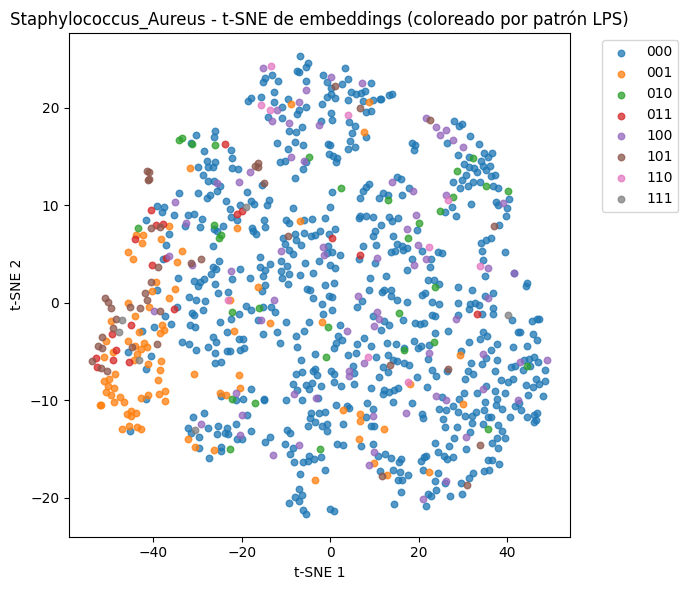

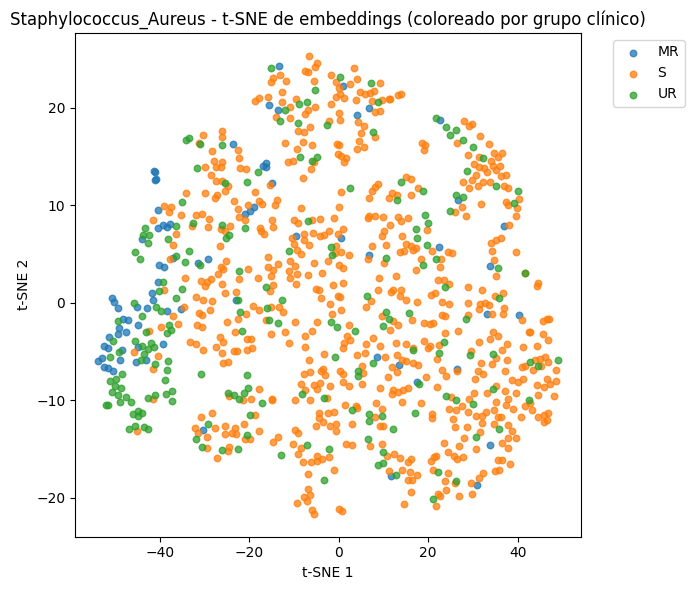

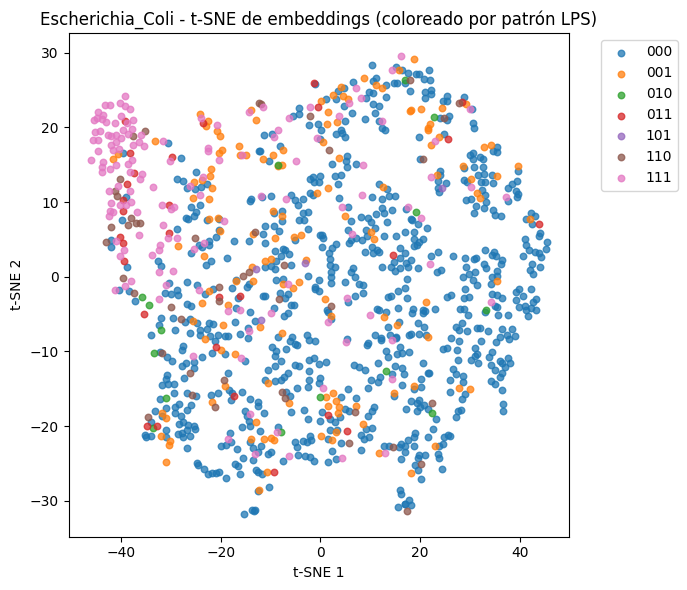

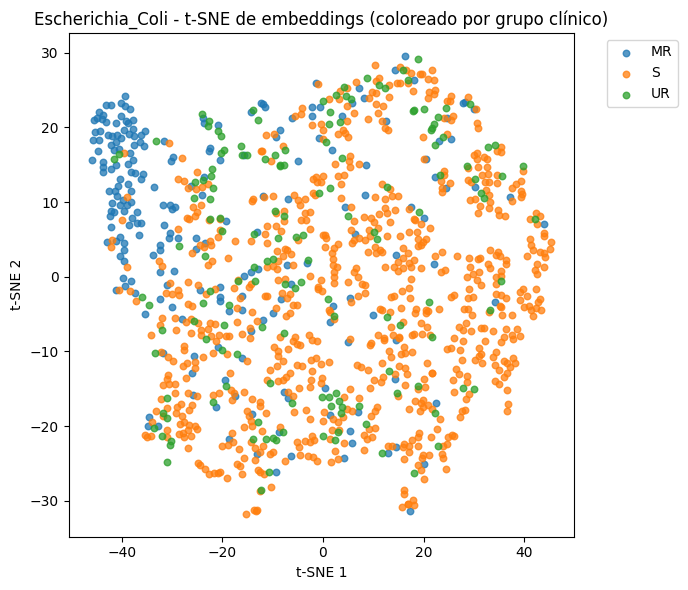

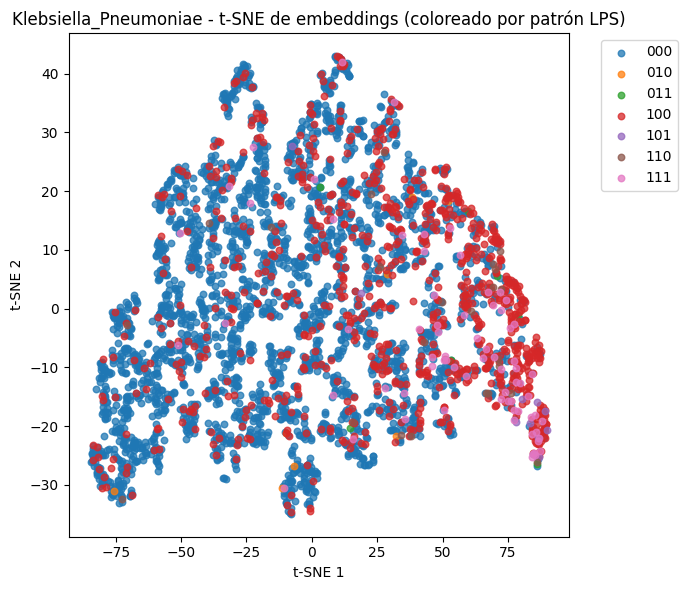

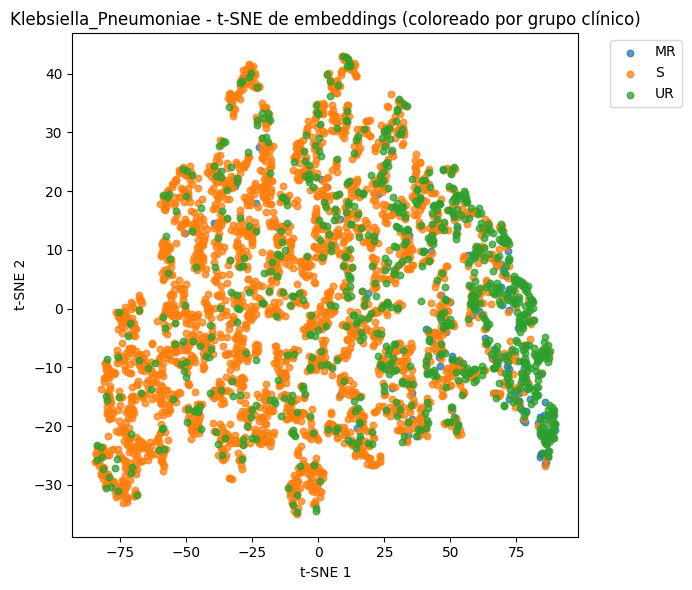

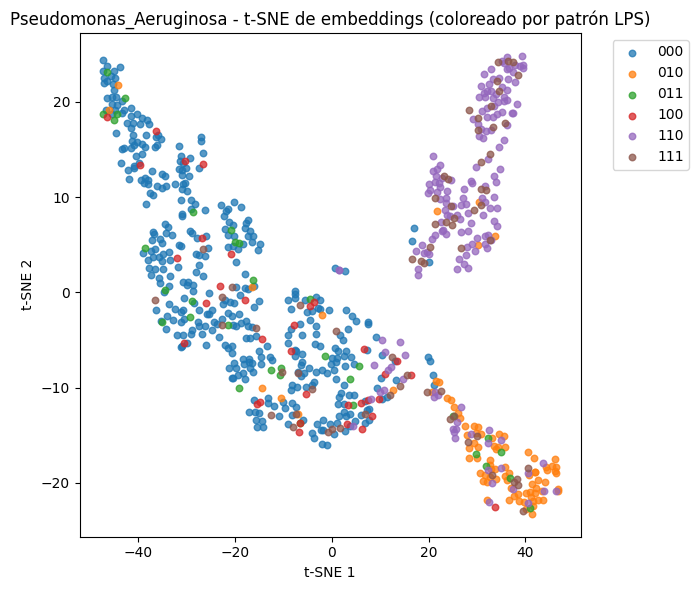

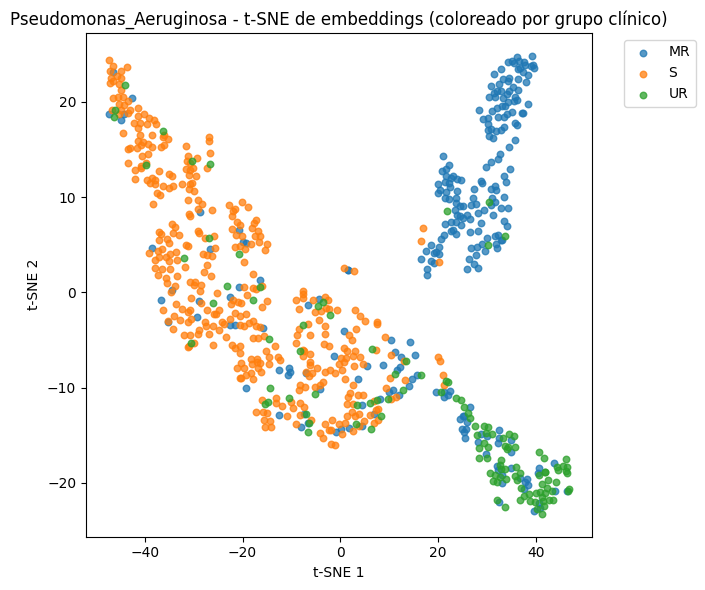

In [13]:
for species in results:
    patt_true = results[species]["patt_test_true"]
    emb = results[species]["test_embeddings"]

    # Vista 1: por patrón real
    plot_tsne_embeddings(
        embeddings=emb,
        labels=patt_true,
        species=species,
        title_suffix="(coloreado por patrón LPS)"
    )

    # Vista 2: por grupo clínico
    clinical_groups = np.array([pattern_to_clinical_group(p) for p in patt_true])
    plot_tsne_embeddings(
        embeddings=emb,
        labels=clinical_groups,
        species=species,
        title_suffix="(coloreado por grupo clínico)"
    )

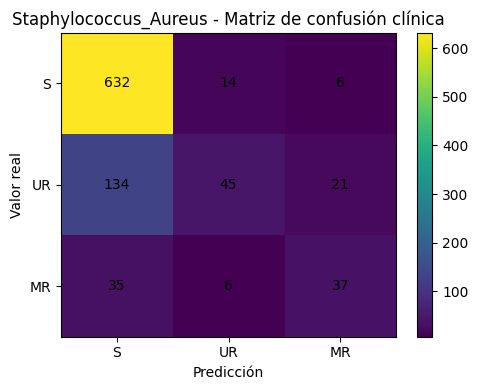


Staphylococcus_Aureus


,S,UR,MR
S,632,14,6
UR,134,45,21
MR,35,6,37


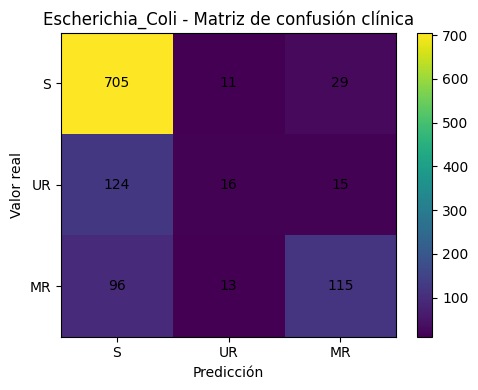


Escherichia_Coli


,S,UR,MR
S,705,11,29
UR,124,16,15
MR,96,13,115


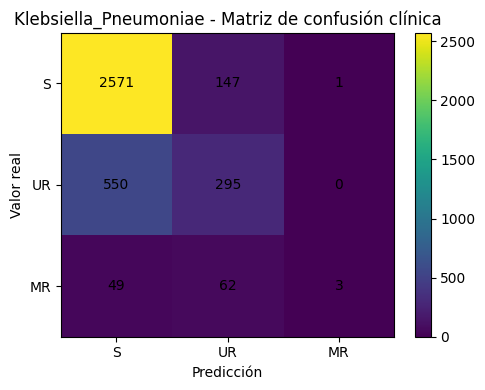


Klebsiella_Pneumoniae


,S,UR,MR
S,2571,147,1
UR,550,295,0
MR,49,62,3


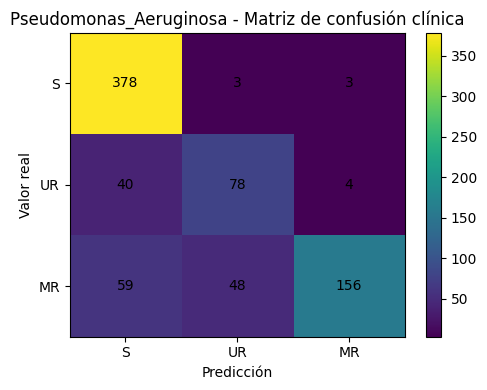


Pseudomonas_Aeruginosa


,S,UR,MR
S,378,3,3
UR,40,78,4
MR,59,48,156


In [14]:
clinical_cms = {}

for species in results:
    cm_df = plot_clinical_confusion_matrix(
        y_true_patterns=results[species]["patt_test_true"],
        y_pred_patterns=results[species]["patt_test_pred"],
        species=species
    )
    clinical_cms[species] = cm_df

    print("\n" + "="*70)
    print(species)
    print("="*70)
    display(cm_df)

In [15]:
from sklearn.metrics import accuracy_score, f1_score, hamming_loss

def compute_multilabel_metrics(patterns_true, patterns_pred):

    # convertir patrones a arrays binarios
    y_true = np.array([[int(c) for c in p] for p in patterns_true])
    y_pred = np.array([[int(c) for c in p] for p in patterns_pred])

    # Accuracy multilabel (exact match por muestra)
    acc = accuracy_score(y_true, y_pred)

    # Hamming loss
    hl = hamming_loss(y_true, y_pred)

    # Weighted F1
    wf1 = f1_score(
        y_true.flatten(),
        y_pred.flatten(),
        average="weighted"
    )

    return acc, hl, wf1

In [16]:
metric_rows = []

for species in results:

    patt_true = results[species]["patt_test_true"]
    patt_pred = results[species]["patt_test_pred"]

    acc, hl, wf1 = compute_multilabel_metrics(
        patt_true,
        patt_pred
    )

    metric_rows.append({
        "species": species,
        "ACC": acc,
        "HL": hl,
        "WF1": wf1
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df

,species,ACC,HL,WF1
0,Staphylococcus_Aureus,0.755914,0.101434,0.884829
1,Escherichia_Coli,0.717972,0.163701,0.824741
2,Klebsiella_Pneumoniae,0.779500,0.085010,0.900171
3,Pseudomonas_Aeruginosa,0.751625,0.124404,0.866491


# Hierarchical multitask LPS model for AMR prediction from MALDI-TOF spectra

The model is designed to predict resistance patterns at two levels:

## 1. Fine objective
The model predicts the **exact LPS resistance pattern** for a given species.

Examples:
- for 3 antibiotics: `SSS`, `RSS`, `SRS`, `SSR`, `RRS`, `RSR`, `SRR`, `RRR`
- for 4 antibiotics: `SSSS`, `RSSS`, `SRSS`, `SSRS`, `SSSR`, `RRSS`, ...

This is the main task.

## 2. Coarse objective
The model also predicts a **coarse resistance category**, designed to emphasize the biologically interesting structure of the patterns:

- `SENSITIVE` → all antibiotics susceptible
- each **single-resistance pattern** is kept as its own coarse class
- `MULTI` → any pattern with two or more resistant antibiotics

Examples:
- `SSS` → `SENSITIVE`
- `RSS` → `RSS`
- `SRS` → `SRS`
- `SSR` → `SSR`
- `RRS`, `RSR`, `SRR`, `RRR` → `MULTI`

For 4 antibiotics:
- `SSSS` → `SENSITIVE`
- `RSSS` → `RSSS`
- `SRSS` → `SRSS`
- `SSRS` → `SSRS`
- `SSSR` → `SSSR`
- `RRSS`, `RRSR`, `RRRR`, etc. → `MULTI`


## Why this architecture?

In previous experiments, the most difficult patterns to separate in embedding space were the **single-resistance patterns**. A standard LPS model often tends to collapse these patterns towards:

- the fully susceptible group, or
- the broader multi-resistance clusters.

To address this, we introduce a **hierarchical multitask architecture**:

- the **fine head** preserves the exact pattern prediction task
- the **coarse head** explicitly encourages the network to distinguish:
  - fully susceptible isolates,
  - each single-resistance pattern,
  - multiple-resistance isolates

This should help organize the latent space more meaningfully

## Loss function

The model is trained with a combined objective:

$
L = L_{fine} + \alpha \, L_{coarse}
$

where:

- $L_{fine}$ is a cross-entropy loss on the exact fine pattern
- $L_{coarse}$ is a cross-entropy loss on the coarse hierarchical class

The coarse loss uses **class weights**, because the coarse categories are usually strongly imbalanced. In particular, the `SENSITIVE` class is often much more frequent than the rare single-resistance classes.

The class weights are built as:

$
w_c \propto \frac{1}{\text{frequency}(c)}
$

and then normalized so that their average value is 1.

This prevents the coarse head from collapsing into the majority class.


## Model selection

Training uses:

- `max_epochs = 1500`
- `patience = 50`
- early stopping based on **validation weighted F1 of the fine task**

The optimization target is therefore the **weighted F1 score on the exact pattern classification problem**.



## Final evaluation

Although the model is trained as a single-label pattern classifier, the final metrics are computed exactly as described in the paper:

1. the predicted fine pattern is decoded into binary labels per antibiotic
2. the predicted multilabel outputs are compared to the true AMR labels
3. the following metrics are reported:
   - Accuracy
   - Hamming Loss
   - Weighted F1

Thus, evaluation is performed as a **binary classification problem per antibiotic**, not as a multiclass problem.

In [22]:
import os
import copy
import pickle
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    hamming_loss,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.manifold import TSNE

SEED = 42
TEST_SIZE = 0.20
VAL_SIZE_WITHIN_TRAIN = 0.20
MAX_EPOCHS = 1500
PATIENCE = 50
BATCH_SIZE = 128
MIN_PATTERN_COUNT = 10
ALPHA_COARSE = 1.0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [23]:
driams_path = "/export/usuarios01/egarroyo/MALDI_for_AMR_prediction/data/DRIAMS_A_AMR_whole_pipeline_23_DRIAMS.pkl"
marisma_path = "/export/usuarios01/egarroyo/MALDI_for_AMR_prediction/data/MARISMa_study_MARISMA_whole_pipeline.pkl"

with open(driams_path, "rb") as f:
    driams_payload = pickle.load(f)

with open(marisma_path, "rb") as f:
    marisma_payload = pickle.load(f)

print("Datasets loaded.")

Datasets loaded.


In [24]:
species_antibiotics = {
    "Staphylococcus_Aureus": [
        "Oxacillin", "Clindamycin", "Fusidic acid"
    ],
    "Escherichia_Coli": [
        "Ciprofloxacin", "Ceftriaxone", "Cefepime"
    ],
    "Klebsiella_Pneumoniae": [
        "Ciprofloxacin", "Imipenem", "Meropenem"
    ],
    "Pseudomonas_Aeruginosa": [
        "Ciprofloxacin", "Imipenem", "Meropenem"
    ]
}

mlp_lps_params = {
    "Escherichia_Coli": dict(
        hidden_layer_sizes=(481, 24, 500),
        activation="relu",
        learning_rate_init=2.4378878006413237e-05
    ),
    "Klebsiella_Pneumoniae": dict(
        hidden_layer_sizes=(94, 313, 99),
        activation="tanh",
        learning_rate_init=7.693489492906515e-05
    ),
    "Pseudomonas_Aeruginosa": dict(
        hidden_layer_sizes=(402, 208, 435),
        activation="relu",
        learning_rate_init=0.004215968282365892
    ),
    "Staphylococcus_Aureus": dict(
        hidden_layer_sizes=(289, 242, 189),
        activation="identity",
        learning_rate_init=0.0008078817205716293
    ),
}

In [25]:
def inspect_dataset(payload, name):
    X = payload["data"]
    y_species = payload["label"]
    amr = payload["amr"]
    antibiotics = payload["antibiotics"]

    print(f"\n{name}")
    print("-" * 50)
    print("Spectra shape:", X.shape)
    print("AMR matrix shape:", amr.shape)
    print("Number of antibiotics:", len(antibiotics))
    print("Unique species:", np.unique(y_species))


inspect_dataset(driams_payload, "DRIAMS")
inspect_dataset(marisma_payload, "MARISMA")


DRIAMS
--------------------------------------------------
Spectra shape: (18168, 6000)
AMR matrix shape: (18168, 9)
Number of antibiotics: 9
Unique species: ['Escherichia_Coli' 'Klebsiella_Pneumoniae' 'Pseudomonas_Aeruginosa'
 'Staphylococcus_Aureus']

MARISMA
--------------------------------------------------
Spectra shape: (21360, 6000)
AMR matrix shape: (21360, 8)
Number of antibiotics: 8
Unique species: ['Escherichia_Coli' 'Klebsiella_Pneumoniae' 'Pseudomonas_Aeruginosa'
 'Staphylococcus_Aureus']


In [26]:
def extract_species_dataset(payload, species, antibiotics_subset):
    X = payload["data"]
    y = payload["label"]
    amr = payload["amr"]
    antibiotics = payload["antibiotics"]

    mask_species = y == species
    X_species = X[mask_species]
    amr_species = amr[mask_species]

    available_ab = [ab for ab in antibiotics_subset if ab in antibiotics]

    if len(available_ab) == 0:
        return None, None, []

    ab_idx = [antibiotics.index(ab) for ab in available_ab]
    amr_species = amr_species[:, ab_idx]

    return X_species, amr_species, available_ab


def align_matrix(payload, species, antibiotics_final):
    X = payload["data"]
    y = payload["label"]
    amr = payload["amr"]
    antibiotics = payload["antibiotics"]

    mask = y == species
    X_species = X[mask]
    amr_species = amr[mask]

    Y = np.full((amr_species.shape[0], len(antibiotics_final)), np.nan)

    for j, ab in enumerate(antibiotics_final):
        if ab in antibiotics:
            idx = antibiotics.index(ab)
            Y[:, j] = amr_species[:, idx]

    return X_species, Y


def remove_missing(X, y):
    mask_valid = ~np.isnan(X).any(axis=1) & ~np.isnan(y).any(axis=1)
    return X[mask_valid], y[mask_valid]


def compute_lps_patterns(y):
    return np.array(["".join(map(str, row.astype(int))) for row in y])


def filter_rare_patterns(X, y, min_samples=10):
    patterns = compute_lps_patterns(y)
    counts = Counter(patterns)
    valid_patterns = {p for p, c in counts.items() if c >= min_samples}
    mask = np.array([p in valid_patterns for p in patterns])
    return X[mask], y[mask], patterns[mask]


def count_resistances(pattern):
    return pattern.count("1")


def fine_to_coarse(pattern):
    n_r = count_resistances(pattern)
    if n_r == 0:
        return "SENSITIVE"
    elif n_r == 1:
        return pattern
    else:
        return "MULTI"


def pattern_to_group3(pattern):
    n_r = count_resistances(pattern)
    if n_r == 0:
        return "S"
    elif n_r == 1:
        return "UR"
    else:
        return "MR"

In [27]:
species_datasets = {}

for species, ab_list in species_antibiotics.items():
    print(f"\nProcessing: {species}")

    X_d_tmp, y_d_tmp, ab_d = extract_species_dataset(driams_payload, species, ab_list)
    X_m_tmp, y_m_tmp, ab_m = extract_species_dataset(marisma_payload, species, ab_list)

    if X_d_tmp is None and X_m_tmp is None:
        print("No antibiotics available.")
        continue

    final_antibiotics = sorted(list(set(ab_d).union(set(ab_m))))
    print("Final antibiotics:", final_antibiotics)

    X_d, y_d = align_matrix(driams_payload, species, final_antibiotics)
    X_m, y_m = align_matrix(marisma_payload, species, final_antibiotics)

    X = np.vstack([X_d, X_m])
    y = np.vstack([y_d, y_m])

    origin_raw = np.array(["DRIAMS"] * X_d.shape[0] + ["MARISMA"] * X_m.shape[0])

    X_raw = X.copy()
    y_raw = y.copy()

    X, y = remove_missing(X, y)
    X, y, patterns = filter_rare_patterns(X, y, min_samples=MIN_PATTERN_COUNT)

    species_datasets[species] = {
        "X": X,
        "y": y,
        "patterns": patterns,
        "antibiotics": final_antibiotics,
        "X_raw": X_raw,
        "y_raw": y_raw,
        "origin_raw": origin_raw
    }

print("\nDone.")


Processing: Staphylococcus_Aureus
Final antibiotics: ['Clindamycin', 'Fusidic acid', 'Oxacillin']

Processing: Escherichia_Coli
Final antibiotics: ['Cefepime', 'Ceftriaxone', 'Ciprofloxacin']

Processing: Klebsiella_Pneumoniae
Final antibiotics: ['Ciprofloxacin', 'Imipenem', 'Meropenem']

Processing: Pseudomonas_Aeruginosa
Final antibiotics: ['Ciprofloxacin', 'Imipenem', 'Meropenem']

Done.


In [28]:
rows = []

for species, dataset in species_datasets.items():
    rows.append({
        "species": species,
        "samples": dataset["X"].shape[0],
        "spectral_features": dataset["X"].shape[1],
        "antibiotics": len(dataset["antibiotics"]),
        "n_patterns": len(np.unique(dataset["patterns"]))
    })

species_stats = pd.DataFrame(rows).sort_values("samples", ascending=False)
species_stats

,species,samples,spectral_features,antibiotics,n_patterns
2,Klebsiella_Pneumoniae,18386,6000,3,7
1,Escherichia_Coli,5616,6000,3,7
0,Staphylococcus_Aureus,4649,6000,3,8
3,Pseudomonas_Aeruginosa,3843,6000,3,6


In [29]:
for species, dataset in species_datasets.items():
    print("\n" + "=" * 70)
    print(species)
    print("=" * 70)

    counts = Counter(dataset["patterns"])
    df = pd.DataFrame({
        "pattern": list(counts.keys()),
        "count": list(counts.values())
    }).sort_values("count", ascending=False)
    df["frequency"] = df["count"] / df["count"].sum()
    df["coarse"] = df["pattern"].map(fine_to_coarse)
    display(df)


Staphylococcus_Aureus


,pattern,count,frequency,coarse
0,000,3260,0.701226,SENSITIVE
6,001,457,0.098301,001
2,100,378,0.081308,100
1,101,211,0.045386,MULTI
3,010,166,0.035707,010
4,011,99,0.021295,MULTI
7,110,48,0.010325,MULTI
5,111,30,0.006453,MULTI



Escherichia_Coli


,pattern,count,frequency,coarse
1,000,3723,0.662927,SENSITIVE
2,111,722,0.128561,MULTI
0,001,701,0.124822,001
3,110,229,0.040776,MULTI
6,011,143,0.025463,MULTI
4,010,76,0.013533,010
5,101,22,0.003917,MULTI



Klebsiella_Pneumoniae


,pattern,count,frequency,coarse
0,000,13592,0.739258,SENSITIVE
1,100,4186,0.227673,100
3,111,359,0.019526,MULTI
6,110,119,0.006472,MULTI
4,101,54,0.002937,MULTI
2,011,38,0.002067,MULTI
5,010,38,0.002067,010



Pseudomonas_Aeruginosa


,pattern,count,frequency,coarse
0,000,1918,0.499089,SENSITIVE
2,110,818,0.212855,MULTI
3,010,440,0.114494,010
5,111,331,0.086131,MULTI
1,100,171,0.044496,100
4,011,165,0.042935,MULTI


In [30]:
def get_activation(name):
    if name == "relu":
        return nn.ReLU()
    elif name == "tanh":
        return nn.Tanh()
    elif name == "identity":
        return nn.Identity()
    else:
        raise ValueError(f"Unsupported activation: {name}")

In [31]:
class HierarchicalMultitaskMLP(nn.Module):
    def __init__(self, input_dim, hidden_layer_sizes, n_fine_classes, n_coarse_classes, activation="relu"):
        super().__init__()

        dims = [input_dim] + list(hidden_layer_sizes)

        self.hidden_linears = nn.ModuleList()
        self.hidden_activations = nn.ModuleList()

        for i in range(len(dims) - 1):
            self.hidden_linears.append(nn.Linear(dims[i], dims[i + 1]))
            self.hidden_activations.append(get_activation(activation))

        self.fine_head = nn.Linear(dims[-1], n_fine_classes)
        self.coarse_head = nn.Linear(dims[-1], n_coarse_classes)

    def forward(self, x, return_embedding=False):
        h = x
        for linear, act in zip(self.hidden_linears, self.hidden_activations):
            h = act(linear(h))

        embedding = h
        fine_logits = self.fine_head(embedding)
        coarse_logits = self.coarse_head(embedding)

        if return_embedding:
            return fine_logits, coarse_logits, embedding

        return fine_logits, coarse_logits

In [32]:
def compute_class_weights(y_classes):
    counts = Counter(y_classes)
    n_classes = len(np.unique(y_classes))

    weights = np.zeros(n_classes, dtype=np.float32)

    for c in range(n_classes):
        weights[c] = 1.0 / counts[c]

    weights = weights / weights.mean()
    return weights

In [33]:
class MultitaskDataset(torch.utils.data.Dataset):
    def __init__(self, X, y_fine, y_coarse):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_fine = torch.tensor(y_fine, dtype=torch.long)
        self.y_coarse = torch.tensor(y_coarse, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_fine[idx], self.y_coarse[idx]


def make_multitask_loader(X, y_fine, y_coarse, batch_size=128, shuffle=False):
    ds = MultitaskDataset(X, y_fine, y_coarse)
    return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

In [34]:
def evaluate_fine_weighted_f1(model, X, y_fine, batch_size=256):
    model.eval()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(y_fine, dtype=torch.long)
        ),
        batch_size=batch_size,
        shuffle=False
    )

    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            fine_logits, _ = model(xb)
            pred = torch.argmax(fine_logits, dim=1).cpu().numpy()
            preds.append(pred)
            trues.append(yb.numpy())

    preds = np.concatenate(preds)
    trues = np.concatenate(trues)

    return f1_score(trues, preds, average="weighted")

In [49]:
def train_hierarchical_model(
    model,
    train_loader,
    val_X,
    val_y_fine,
    coarse_class_weights,
    lr,
    alpha_coarse=0.5,
    max_epochs=1500,
    patience=50
):
    fine_criterion = nn.CrossEntropyLoss()
    coarse_criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(coarse_class_weights, dtype=torch.float32, device=device)
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_val_f1 = -np.inf
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_fine_weighted_f1": []
    }

    for epoch in range(max_epochs):
        model.train()
        batch_losses = []

        for xb, yb_fine, yb_coarse in train_loader:
            xb = xb.to(device)
            yb_fine = yb_fine.to(device)
            yb_coarse = yb_coarse.to(device)

            optimizer.zero_grad()

            fine_logits, coarse_logits = model(xb)

            loss_fine = fine_criterion(fine_logits, yb_fine)
            loss_coarse = coarse_criterion(coarse_logits, yb_coarse)
            loss = loss_fine + alpha_coarse * loss_coarse

            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)
        val_f1 = evaluate_fine_weighted_f1(model, val_X, val_y_fine)

        history["train_loss"].append(train_loss)
        history["val_fine_weighted_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(
                f"Epoch {epoch+1:4d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_fine_wF1={val_f1:.4f}"
            )

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [36]:
def predict_fine_classes(model, X, batch_size=256):
    model.eval()

    loader = torch.utils.data.DataLoader(
        torch.tensor(X, dtype=torch.float32),
        batch_size=batch_size,
        shuffle=False
    )

    preds = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(device)
            fine_logits, _ = model(xb)
            pred = torch.argmax(fine_logits, dim=1).cpu().numpy()
            preds.append(pred)

    return np.concatenate(preds)


def predict_fine_probs(model, X, batch_size=256):
    model.eval()

    loader = torch.utils.data.DataLoader(
        torch.tensor(X, dtype=torch.float32),
        batch_size=batch_size,
        shuffle=False
    )

    probs = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(device)
            fine_logits, _ = model(xb)
            p = torch.softmax(fine_logits, dim=1).cpu().numpy()
            probs.append(p)

    return np.vstack(probs)


def extract_embeddings(model, X, batch_size=256):
    model.eval()

    loader = torch.utils.data.DataLoader(
        torch.tensor(X, dtype=torch.float32),
        batch_size=batch_size,
        shuffle=False
    )

    embs = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(device)
            _, _, emb = model(xb, return_embedding=True)
            embs.append(emb.cpu().numpy())

    return np.vstack(embs)

In [37]:
def patterns_to_binary_matrix(patterns):
    return np.array([[int(c) for c in p] for p in patterns], dtype=int)


def compute_paper_metrics(patterns_true, patterns_pred):
    y_true = patterns_to_binary_matrix(patterns_true)
    y_pred = patterns_to_binary_matrix(patterns_pred)

    acc = accuracy_score(y_true, y_pred)
    hl = hamming_loss(y_true, y_pred)
    wf1 = f1_score(y_true.flatten(), y_pred.flatten(), average="weighted")

    return acc, hl, wf1

In [38]:
def patterns_to_antibiotic_probs(pattern_probs, patterns):
    n_samples = pattern_probs.shape[0]
    n_antibiotics = len(patterns[0])

    ab_probs = np.zeros((n_samples, n_antibiotics), dtype=float)

    for p_idx, pattern in enumerate(patterns):
        for ab_idx, c in enumerate(pattern):
            if c == "1":
                ab_probs[:, ab_idx] += pattern_probs[:, p_idx]

    return ab_probs


def compute_macro_roc_auc(patterns_true, pattern_probs, pattern_order):
    y_true = patterns_to_binary_matrix(patterns_true)
    ab_probs = patterns_to_antibiotic_probs(pattern_probs, pattern_order)

    aucs = []
    for j in range(y_true.shape[1]):
        if len(np.unique(y_true[:, j])) < 2:
            continue
        auc = roc_auc_score(y_true[:, j], ab_probs[:, j])
        aucs.append(auc)

    if len(aucs) == 0:
        return np.nan, []

    return float(np.mean(aucs)), aucs

In [39]:
def plot_training_history(history, species):
    fig, ax1 = plt.subplots(figsize=(7, 4))

    ax1.plot(history["train_loss"], label="Train loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Train loss")

    ax2 = ax1.twinx()
    ax2.plot(history["val_fine_weighted_f1"], label="Val fine weighted F1")
    ax2.set_ylabel("Val fine weighted F1")

    ax1.set_title(f"{species} - Training history")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.tight_layout()
    plt.show()

In [40]:
def plot_tsne_embeddings(embeddings, labels, species, title_suffix=""):
    perplexity = min(30, max(5, len(embeddings) // 10))

    tsne = TSNE(
        n_components=2,
        random_state=SEED,
        init="pca",
        learning_rate="auto",
        perplexity=perplexity
    )
    emb_2d = tsne.fit_transform(embeddings)

    df_plot = pd.DataFrame({
        "TSNE1": emb_2d[:, 0],
        "TSNE2": emb_2d[:, 1],
        "label": labels
    })

    plt.figure(figsize=(7, 6))

    for lab in sorted(df_plot["label"].unique()):
        sub = df_plot[df_plot["label"] == lab]
        plt.scatter(sub["TSNE1"], sub["TSNE2"], label=lab, alpha=0.75, s=22)

    plt.title(f"{species} - t-SNE {title_suffix}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [41]:
def plot_group3_confusion(patterns_true, patterns_pred, species):
    y_true = [pattern_to_group3(p) for p in patterns_true]
    y_pred = [pattern_to_group3(p) for p in patterns_pred]

    labels = ["S", "UR", "MR"]
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(f"{species} - Confusion matrix (S / UR / MR)")
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels)
    plt.yticks(ticks, labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(cm, index=labels, columns=labels)

In [50]:
results = {}
summary_rows = []

for species, dataset in species_datasets.items():
    print("\n" + "=" * 90)
    print(f"Training hierarchical multitask model for {species}")
    print("=" * 90)

    X = dataset["X"]
    patterns = dataset["patterns"]

    fine_classes = sorted(np.unique(patterns))
    fine_to_idx = {p: i for i, p in enumerate(fine_classes)}
    idx_to_fine = {i: p for p, i in fine_to_idx.items()}

    coarse_labels = np.array([fine_to_coarse(p) for p in patterns])
    coarse_classes = sorted(np.unique(coarse_labels), key=lambda x: (x != "SENSITIVE", x != "MULTI", x))
    coarse_to_idx = {c: i for i, c in enumerate(coarse_classes)}
    idx_to_coarse = {i: c for c, i in coarse_to_idx.items()}

    y_fine = np.array([fine_to_idx[p] for p in patterns], dtype=int)
    y_coarse = np.array([coarse_to_idx[fine_to_coarse(p)] for p in patterns], dtype=int)

    X_train, X_test, y_fine_train, y_fine_test, y_coarse_train, y_coarse_test, patt_train, patt_test = train_test_split(
        X, y_fine, y_coarse, patterns,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y_fine
    )

    X_train_sub, X_val, y_fine_train_sub, y_fine_val, y_coarse_train_sub, y_coarse_val = train_test_split(
        X_train, y_fine_train, y_coarse_train,
        test_size=VAL_SIZE_WITHIN_TRAIN,
        random_state=SEED,
        stratify=y_fine_train
    )

    coarse_weights = compute_class_weights(y_coarse_train_sub)

    train_loader = make_multitask_loader(
        X_train_sub,
        y_fine_train_sub,
        y_coarse_train_sub,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    params = mlp_lps_params[species]

    model = HierarchicalMultitaskMLP(
        input_dim=X.shape[1],
        hidden_layer_sizes=params["hidden_layer_sizes"],
        n_fine_classes=len(fine_classes),
        n_coarse_classes=len(coarse_classes),
        activation=params["activation"]
    ).to(device)

    model, history = train_hierarchical_model(
        model=model,
        train_loader=train_loader,
        val_X=X_val,
        val_y_fine=y_fine_val,
        coarse_class_weights=coarse_weights,
        lr=params["learning_rate_init"],
        alpha_coarse=ALPHA_COARSE,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE
    )

    fine_pred_test = predict_fine_classes(model, X_test)
    fine_probs_test = predict_fine_probs(model, X_test)

    patt_pred_test = np.array([idx_to_fine[i] for i in fine_pred_test])
    patt_true_test = np.array([idx_to_fine[i] for i in y_fine_test])

    fine_acc = accuracy_score(y_fine_test, fine_pred_test)
    fine_macro_f1 = f1_score(y_fine_test, fine_pred_test, average="macro")
    fine_weighted_f1 = f1_score(y_fine_test, fine_pred_test, average="weighted")

    acc_paper, hl_paper, wf1_paper = compute_paper_metrics(patt_true_test, patt_pred_test)

    pattern_order = [idx_to_fine[i] for i in range(len(idx_to_fine))]
    roc_auc_macro, roc_auc_per_ab = compute_macro_roc_auc(
        patt_true_test,
        fine_probs_test,
        pattern_order
    )

    coarse_pred_test = np.array([coarse_to_idx[fine_to_coarse(p)] for p in patt_pred_test])
    coarse_acc = accuracy_score(y_coarse_test, coarse_pred_test)
    coarse_weighted_f1 = f1_score(y_coarse_test, coarse_pred_test, average="weighted")

    test_embeddings = extract_embeddings(model, X_test)

    results[species] = {
        "model": model,
        "history": history,
        "X_test": X_test,
        "fine_classes": fine_classes,
        "fine_to_idx": fine_to_idx,
        "idx_to_fine": idx_to_fine,
        "coarse_classes": coarse_classes,
        "coarse_to_idx": coarse_to_idx,
        "idx_to_coarse": idx_to_coarse,
        "y_fine_test": y_fine_test,
        "y_coarse_test": y_coarse_test,
        "patt_true_test": patt_true_test,
        "patt_pred_test": patt_pred_test,
        "fine_probs_test": fine_probs_test,
        "test_embeddings": test_embeddings,
        "antibiotics": dataset["antibiotics"],
        "roc_auc_per_ab": roc_auc_per_ab
    }

    summary_rows.append({
        "species": species,
        "n_samples": len(X),
        "n_fine_patterns": len(fine_classes),
        "n_coarse_classes": len(coarse_classes),
        "fine_acc": fine_acc,
        "fine_macro_f1": fine_macro_f1,
        "fine_weighted_f1": fine_weighted_f1,
        "coarse_acc": coarse_acc,
        "coarse_weighted_f1": coarse_weighted_f1,
        "paper_ACC": acc_paper,
        "paper_HL": hl_paper,
        "paper_WF1": wf1_paper,
        "paper_ROC_AUC": roc_auc_macro
    })

    print(f"Fine ACC: {fine_acc:.4f}")
    print(f"Fine macro-F1: {fine_macro_f1:.4f}")
    print(f"Fine weighted-F1: {fine_weighted_f1:.4f}")
    print(f"Coarse ACC: {coarse_acc:.4f}")
    print(f"Coarse weighted-F1: {coarse_weighted_f1:.4f}")
    print(f"Paper ACC: {acc_paper:.4f}")
    print(f"Paper HL: {hl_paper:.4f}")
    print(f"Paper WF1: {wf1_paper:.4f}")
    print(f"Paper ROC-AUC: {roc_auc_macro:.4f}")


Training hierarchical multitask model for Staphylococcus_Aureus
Epoch    1 | train_loss=2.7111 | val_fine_wF1=0.5888
Epoch   20 | train_loss=0.1552 | val_fine_wF1=0.7132
Epoch   40 | train_loss=0.0031 | val_fine_wF1=0.6976
Epoch   60 | train_loss=0.0007 | val_fine_wF1=0.6971
Early stopping at epoch 63
Fine ACC: 0.7301
Fine macro-F1: 0.3269
Fine weighted-F1: 0.6917
Coarse ACC: 0.7333
Coarse weighted-F1: 0.6985
Paper ACC: 0.7301
Paper HL: 0.1093
Paper WF1: 0.8784
Paper ROC-AUC: 0.7505

Training hierarchical multitask model for Escherichia_Coli
Epoch    1 | train_loss=3.2279 | val_fine_wF1=0.5286
Epoch   20 | train_loss=2.1400 | val_fine_wF1=0.5521
Epoch   40 | train_loss=1.5294 | val_fine_wF1=0.6427
Epoch   60 | train_loss=1.1075 | val_fine_wF1=0.6743
Epoch   80 | train_loss=0.8470 | val_fine_wF1=0.6860
Epoch  100 | train_loss=0.6397 | val_fine_wF1=0.6890
Epoch  120 | train_loss=0.4996 | val_fine_wF1=0.6971
Epoch  140 | train_loss=0.3694 | val_fine_wF1=0.6982
Epoch  160 | train_loss=0.2

In [51]:
summary_df = pd.DataFrame(summary_rows).sort_values("paper_WF1", ascending=False)
summary_df

,species,n_samples,n_fine_patterns,n_coarse_classes,fine_acc,fine_macro_f1,fine_weighted_f1,coarse_acc,coarse_weighted_f1,paper_ACC,paper_HL,paper_WF1,paper_ROC_AUC
2,Klebsiella_Pneumoniae,18386,7,4,0.769712,0.243702,0.746124,0.771615,0.749516,0.769712,0.088635,0.901289,0.816944
0,Staphylococcus_Aureus,4649,8,5,0.730108,0.326907,0.691705,0.733333,0.698472,0.730108,0.109319,0.878362,0.750453
3,Pseudomonas_Aeruginosa,3843,6,4,0.742523,0.489647,0.715229,0.801040,0.789878,0.742523,0.131339,0.864621,0.817664
1,Escherichia_Coli,5616,7,4,0.713523,0.287704,0.670089,0.733986,0.706719,0.713523,0.161032,0.825505,0.796454


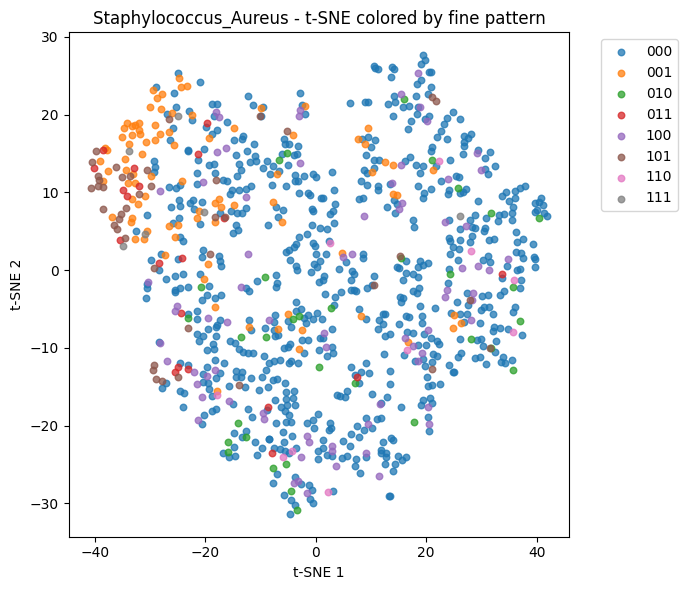

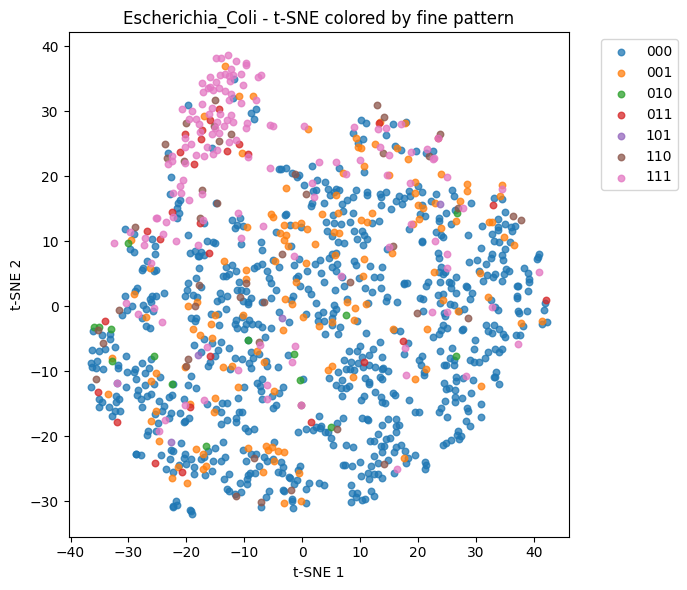

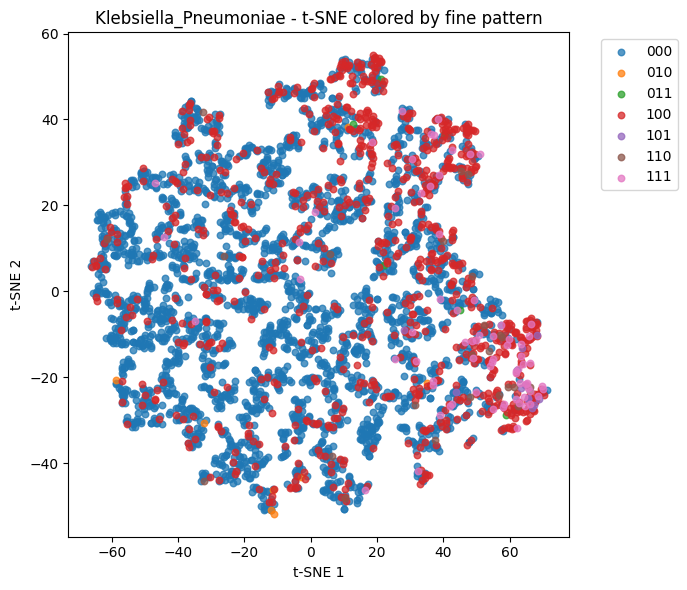

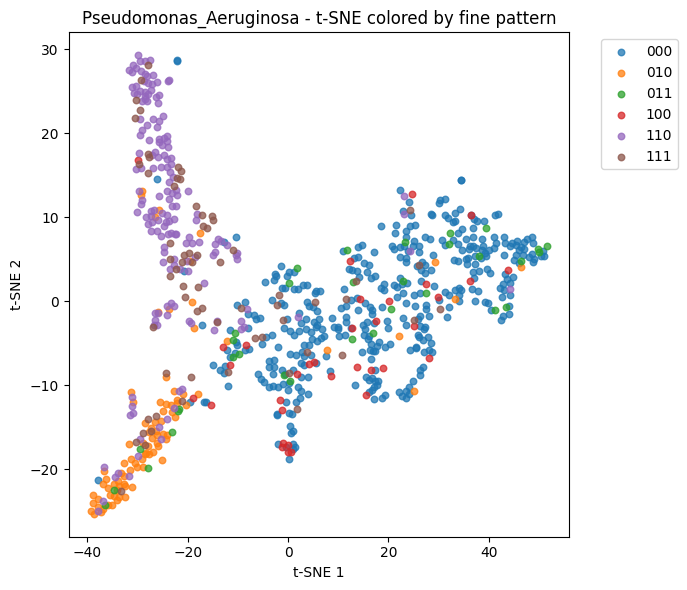

In [52]:
for species in results:
    patt_true = results[species]["patt_true_test"]
    emb = results[species]["test_embeddings"]

    plot_tsne_embeddings(
        emb,
        patt_true,
        species,
        title_suffix="colored by fine pattern"
    )

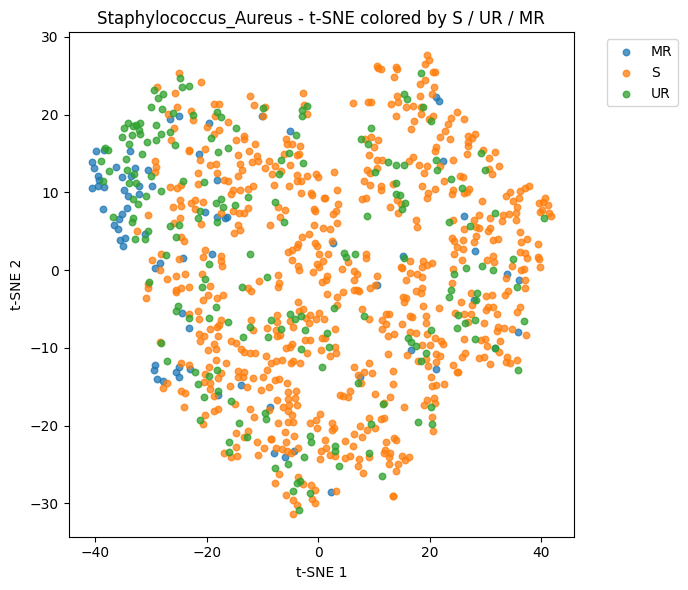

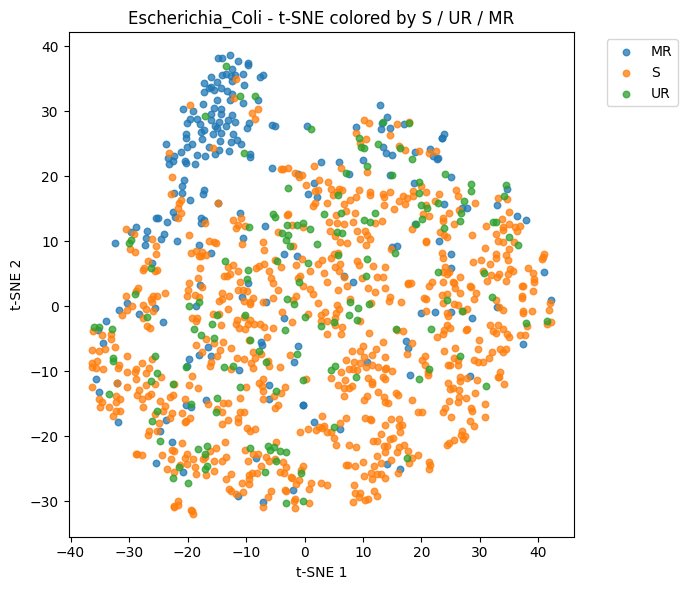

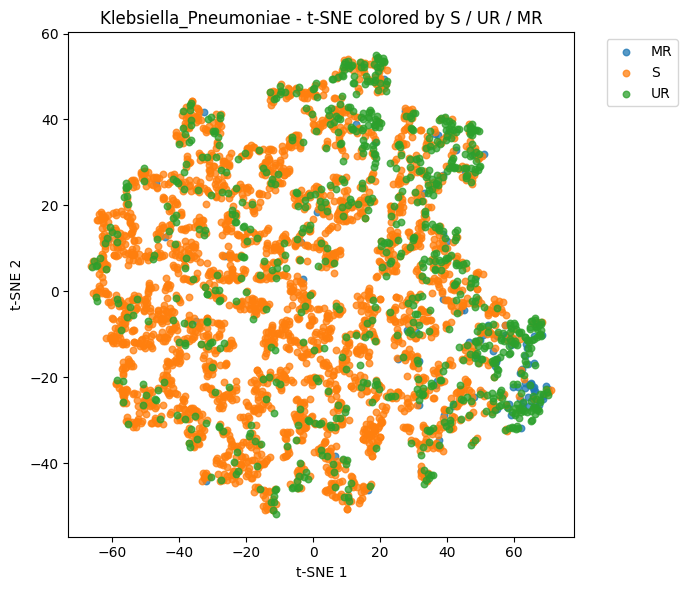

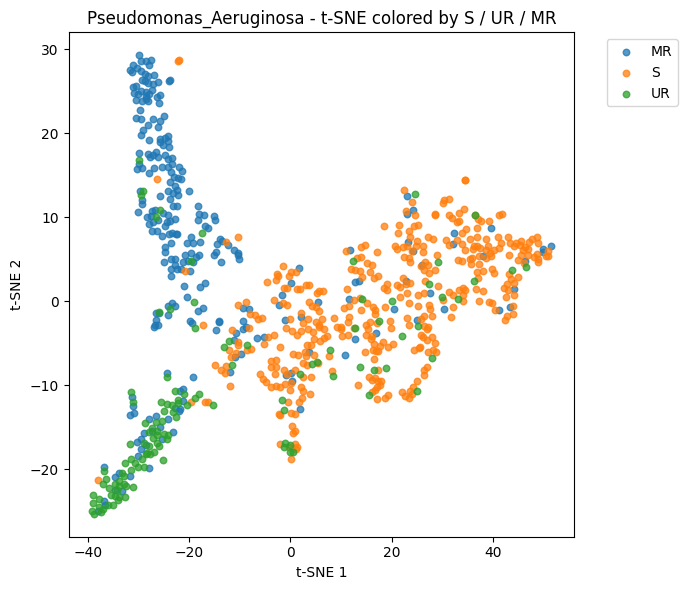

In [53]:
for species in results:
    patt_true = results[species]["patt_true_test"]
    emb = results[species]["test_embeddings"]
    group3 = np.array([pattern_to_group3(p) for p in patt_true])

    plot_tsne_embeddings(
        emb,
        group3,
        species,
        title_suffix="colored by S / UR / MR"
    )

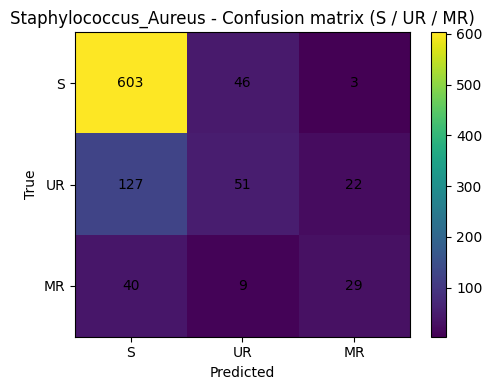


Staphylococcus_Aureus


,S,UR,MR
S,603,46,3
UR,127,51,22
MR,40,9,29


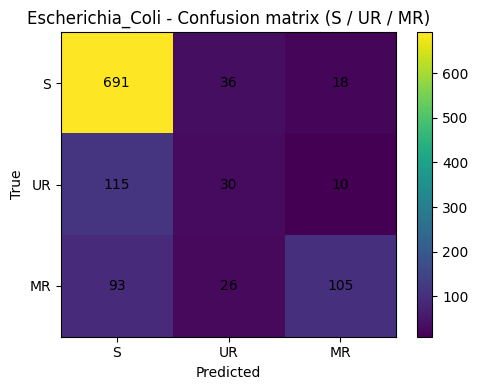


Escherichia_Coli


,S,UR,MR
S,691,36,18
UR,115,30,10
MR,93,26,105


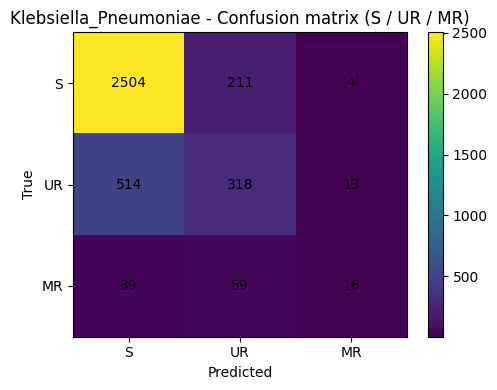


Klebsiella_Pneumoniae


,S,UR,MR
S,2504,211,4
UR,514,318,13
MR,39,59,16


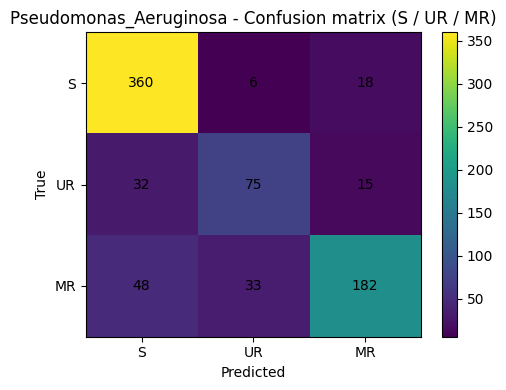


Pseudomonas_Aeruginosa


,S,UR,MR
S,360,6,18
UR,32,75,15
MR,48,33,182


In [54]:
group3_cms = {}

for species in results:
    cm_df = plot_group3_confusion(
        results[species]["patt_true_test"],
        results[species]["patt_pred_test"],
        species
    )
    group3_cms[species] = cm_df

    print("\n" + "=" * 70)
    print(species)
    print("=" * 70)
    display(cm_df)

In [55]:
for species in results:
    y_true_group = [pattern_to_group3(p) for p in results[species]["patt_true_test"]]
    y_pred_group = [pattern_to_group3(p) for p in results[species]["patt_pred_test"]]

    print("\n" + "=" * 90)
    print(f"{species} - classification report for S / UR / MR")
    print("=" * 90)
    print(classification_report(y_true_group, y_pred_group, digits=4))


Staphylococcus_Aureus - classification report for S / UR / MR
              precision    recall  f1-score   support

          MR     0.5370    0.3718    0.4394        78
           S     0.7831    0.9248    0.8481       652
          UR     0.4811    0.2550    0.3333       200

    accuracy                         0.7344       930
   macro avg     0.6004    0.5172    0.5403       930
weighted avg     0.6975    0.7344    0.7031       930


Escherichia_Coli - classification report for S / UR / MR
              precision    recall  f1-score   support

          MR     0.7895    0.4688    0.5882       224
           S     0.7686    0.9275    0.8406       745
          UR     0.3261    0.1935    0.2429       155

    accuracy                         0.7349      1124
   macro avg     0.6281    0.5299    0.5573      1124
weighted avg     0.7118    0.7349    0.7079      1124


Klebsiella_Pneumoniae - classification report for S / UR / MR
              precision    recall  f1-score   support


# Multitask Architecture for AMR Prediction from MALDI-TOF Spectra

In this notebook we explore an improved architecture for antimicrobial resistance prediction using MALDI-TOF spectra.

Previous work using **LPS classifiers** shows that:

- **multi-drug resistance patterns** tend to form clear clusters in embedding space
- **single resistance patterns** are harder to separate

This is biologically plausible:

- multi-resistance often involves **global membrane or proteome changes**
- single resistance mechanisms often involve **specific mutations or enzymes**

These changes may fall **outside the typical MALDI-TOF detection range**, making them harder to detect.

To address this, we propose a **multitask architecture** that explicitly models:

1. the **exact resistance pattern**
2. the **number of resistances**
3. **binary resistance per antibiotic**

This architecture encourages the embedding space to encode biologically meaningful structure.

In [56]:
import os
import copy
import pickle
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    hamming_loss,
    roc_auc_score,
    confusion_matrix
)
from sklearn.manifold import TSNE

In [ ]:
SEED = 42
TEST_SIZE = 0.20
VAL_SIZE_WITHIN_TRAIN = 0.20

MAX_EPOCHS = 1500
PATIENCE = 50
BATCH_SIZE = 128

ALPHA_FINE = 1.0
ALPHA_COUNT = 0.5
ALPHA_BINARY = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Using device:", device)

Using device: cpu


In [ ]:
def count_resistances(pattern):
    return pattern.count("1")


In [58]:
class MultitaskAMRModel(nn.Module):

    def __init__(self, input_dim, hidden_layer_sizes,
                 n_patterns, n_antibiotics, activation="relu"):

        super().__init__()

        dims = [input_dim] + list(hidden_layer_sizes)

        self.hidden = nn.ModuleList()
        self.activations = nn.ModuleList()

        for i in range(len(dims)-1):
            self.hidden.append(nn.Linear(dims[i], dims[i+1]))

            if activation == "relu":
                self.activations.append(nn.ReLU())
            elif activation == "tanh":
                self.activations.append(nn.Tanh())
            else:
                self.activations.append(nn.Identity())

        # HEAD 1 — pattern classification
        self.pattern_head = nn.Linear(dims[-1], n_patterns)

        # HEAD 2 — number of resistances
        self.count_head = nn.Linear(dims[-1], n_antibiotics + 1)

        # HEAD 3 — binary per antibiotic
        self.binary_head = nn.Linear(dims[-1], n_antibiotics)

    def forward(self, x, return_embedding=False):

        h = x

        for linear, act in zip(self.hidden, self.activations):
            h = act(linear(h))

        embedding = h

        pattern_logits = self.pattern_head(embedding)
        count_logits = self.count_head(embedding)
        binary_logits = self.binary_head(embedding)

        if return_embedding:
            return pattern_logits, count_logits, binary_logits, embedding

        return pattern_logits, count_logits, binary_logits

In [60]:
class MultitaskDataset(torch.utils.data.Dataset):

    def __init__(self, X, y_pattern, y_count, y_binary):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_pattern = torch.tensor(y_pattern, dtype=torch.long)
        self.y_count = torch.tensor(y_count, dtype=torch.long)
        self.y_binary = torch.tensor(y_binary, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y_pattern[idx],
            self.y_count[idx],
            self.y_binary[idx]
        )

In [61]:
def train_multitask_model(
    model,
    train_loader,
    val_X,
    val_patterns,
    lr,
    max_epochs=1500,
    patience=50
):

    pattern_loss_fn = nn.CrossEntropyLoss()
    count_loss_fn = nn.CrossEntropyLoss()
    binary_loss_fn = nn.BCEWithLogitsLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_f1 = -np.inf
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_f1": []
    }

    for epoch in range(max_epochs):

        model.train()
        losses = []

        for xb, y_pattern, y_count, y_binary in train_loader:

            xb = xb.to(device)
            y_pattern = y_pattern.to(device)
            y_count = y_count.to(device)
            y_binary = y_binary.to(device)

            optimizer.zero_grad()

            pattern_logits, count_logits, binary_logits = model(xb)

            loss_pattern = pattern_loss_fn(pattern_logits, y_pattern)
            loss_count = count_loss_fn(count_logits, y_count)
            loss_binary = binary_loss_fn(binary_logits, y_binary)

            loss = (
                ALPHA_FINE * loss_pattern +
                ALPHA_COUNT * loss_count +
                ALPHA_BINARY * loss_binary
            )

            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        train_loss = np.mean(losses)

        val_f1 = evaluate_pattern_f1(model, val_X, val_patterns)

        history["train_loss"].append(train_loss)
        history["val_f1"].append(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping")
            break

    model.load_state_dict(best_state)

    return model, history

In [62]:
def evaluate_pattern_f1(model, X, y_pattern):

    model.eval()

    loader = torch.utils.data.DataLoader(
        torch.tensor(X, dtype=torch.float32),
        batch_size=256
    )

    preds = []

    with torch.no_grad():

        for xb in loader:

            xb = xb.to(device)

            logits, _, _ = model(xb)

            pred = torch.argmax(logits, dim=1)

            preds.append(pred.cpu().numpy())

    preds = np.concatenate(preds)

    return f1_score(y_pattern, preds, average="weighted")

In [63]:
def predict_pattern_probs(model, X):

    model.eval()

    loader = torch.utils.data.DataLoader(
        torch.tensor(X, dtype=torch.float32),
        batch_size=256
    )

    probs = []

    with torch.no_grad():

        for xb in loader:

            xb = xb.to(device)

            logits, _, _ = model(xb)

            p = torch.softmax(logits, dim=1)

            probs.append(p.cpu().numpy())

    return np.vstack(probs)

In [64]:
def extract_embeddings(model, X):

    model.eval()

    loader = torch.utils.data.DataLoader(
        torch.tensor(X, dtype=torch.float32),
        batch_size=256
    )

    embs = []

    with torch.no_grad():

        for xb in loader:

            xb = xb.to(device)

            _, _, _, emb = model(xb, return_embedding=True)

            embs.append(emb.cpu().numpy())

    return np.vstack(embs)

In [65]:
def patterns_to_binary(patterns):

    return np.array([
        [int(c) for c in p]
        for p in patterns
    ])


def compute_paper_metrics(patterns_true, patterns_pred):

    y_true = patterns_to_binary(patterns_true)
    y_pred = patterns_to_binary(patterns_pred)

    acc = accuracy_score(y_true, y_pred)
    hl = hamming_loss(y_true, y_pred)
    wf1 = f1_score(y_true.flatten(), y_pred.flatten(), average="weighted")

    return acc, hl, wf1

In [66]:
def patterns_to_antibiotic_probs(pattern_probs, patterns):

    n_samples = pattern_probs.shape[0]
    n_antibiotics = len(patterns[0])

    ab_probs = np.zeros((n_samples, n_antibiotics))

    for p_idx, pattern in enumerate(patterns):

        for ab_idx, c in enumerate(pattern):

            if c == "1":
                ab_probs[:, ab_idx] += pattern_probs[:, p_idx]

    return ab_probs


def compute_macro_auc(patterns_true, pattern_probs, pattern_list):

    y_true = patterns_to_binary(patterns_true)
    ab_probs = patterns_to_antibiotic_probs(pattern_probs, pattern_list)

    aucs = []

    for i in range(y_true.shape[1]):

        if len(np.unique(y_true[:, i])) < 2:
            continue

        auc = roc_auc_score(y_true[:, i], ab_probs[:, i])

        aucs.append(auc)

    return np.mean(aucs)

In [67]:
def plot_tsne(embeddings, labels, species):

    tsne = TSNE(n_components=2, random_state=SEED)

    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(7,6))

    for l in np.unique(labels):

        mask = labels == l

        plt.scatter(
            emb_2d[mask,0],
            emb_2d[mask,1],
            label=l,
            s=20,
            alpha=0.7
        )

    plt.legend()
    plt.title(species)
    plt.show()


Running multitask experiment: Staphylococcus_Aureus
Early stopping
ACC: 0.7258064516129032
HL: 0.10967741935483871
WF1: 0.8778540071168872
ROC AUC: 0.7504055899890845


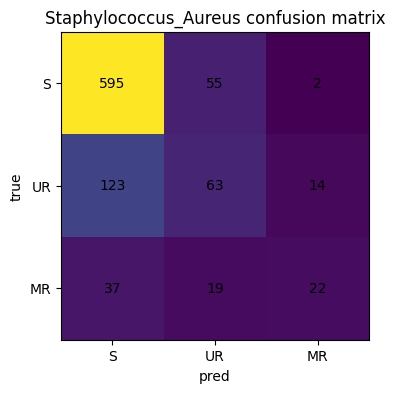

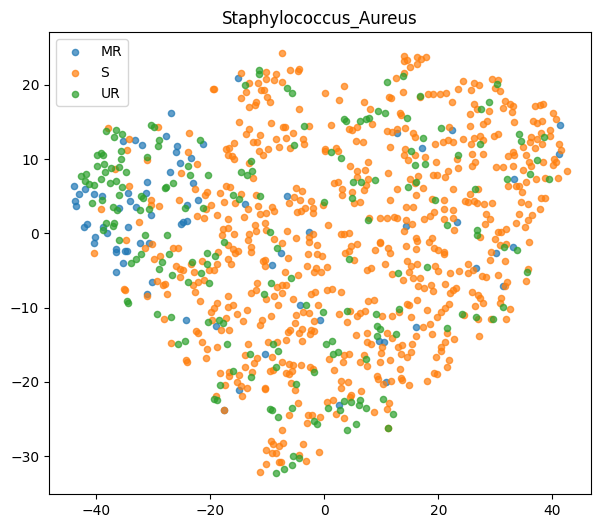


Running multitask experiment: Escherichia_Coli
Early stopping
ACC: 0.6841637010676157
HL: 0.17823250296559906
WF1: 0.8153852827957144
ROC AUC: 0.7848486360791349


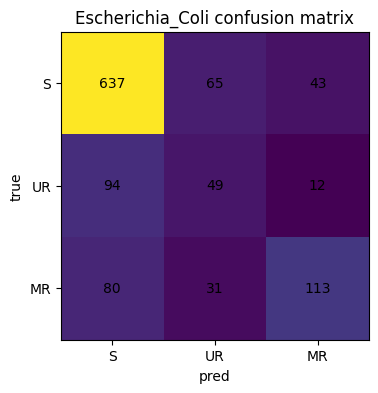

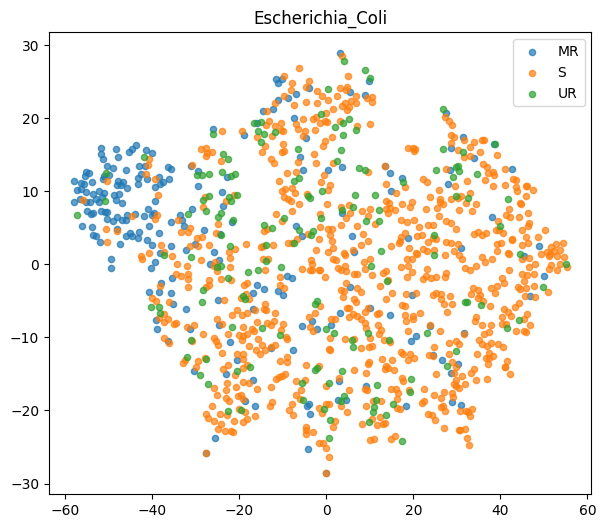


Running multitask experiment: Klebsiella_Pneumoniae


In [ ]:
results = []
models = {}

for species, dataset in species_datasets.items():

    print("\n"+"="*80)
    print("Running multitask experiment:", species)
    print("="*80)

    X = dataset["X"]
    patterns = dataset["patterns"]
    antibiotics = dataset["antibiotics"]

    n_antibiotics = len(antibiotics)

    # ------------------------------
    # build labels
    # ------------------------------

    fine_patterns = sorted(np.unique(patterns))
    fine_to_idx = {p:i for i,p in enumerate(fine_patterns)}
    idx_to_fine = {i:p for p,i in fine_to_idx.items()}

    y_pattern = np.array([fine_to_idx[p] for p in patterns])

    y_binary = np.array([[int(c) for c in p] for p in patterns])

    y_count = np.array([count_resistances(p) for p in patterns])

    # ------------------------------
    # split
    # ------------------------------

    X_train, X_test, y_pattern_train, y_pattern_test, patt_train, patt_test = train_test_split(
        X,
        y_pattern,
        patterns,
        test_size=TEST_SIZE,
        stratify=y_pattern,
        random_state=SEED
    )

    X_train_sub, X_val, y_pattern_train_sub, y_pattern_val = train_test_split(
        X_train,
        y_pattern_train,
        test_size=VAL_SIZE_WITHIN_TRAIN,
        stratify=y_pattern_train,
        random_state=SEED
    )

    # binary + count labels
    y_binary_train_sub = np.array([[int(c) for c in fine_patterns[i]] for i in y_pattern_train_sub])
    y_binary_val = np.array([[int(c) for c in fine_patterns[i]] for i in y_pattern_val])
    y_binary_test = np.array([[int(c) for c in fine_patterns[i]] for i in y_pattern_test])

    y_count_train_sub = np.array([count_resistances(fine_patterns[i]) for i in y_pattern_train_sub])
    y_count_val = np.array([count_resistances(fine_patterns[i]) for i in y_pattern_val])
    y_count_test = np.array([count_resistances(fine_patterns[i]) for i in y_pattern_test])

    # ------------------------------
    # dataloader
    # ------------------------------

    train_loader = torch.utils.data.DataLoader(
        MultitaskDataset(
            X_train_sub,
            y_pattern_train_sub,
            y_count_train_sub,
            y_binary_train_sub
        ),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    params = mlp_lps_params[species]

    model = MultitaskAMRModel(
        input_dim=X.shape[1],
        hidden_layer_sizes=params["hidden_layer_sizes"],
        n_patterns=len(fine_patterns),
        n_antibiotics=n_antibiotics,
        activation=params["activation"]
    ).to(device)

    model, history = train_multitask_model(
        model,
        train_loader,
        X_val,
        y_pattern_val,
        lr=params["learning_rate_init"]
    )

    models[species] = model

    # ------------------------------
    # predictions
    # ------------------------------

    probs = predict_pattern_probs(model, X_test)

    preds = np.argmax(probs, axis=1)

    patt_pred = np.array([idx_to_fine[i] for i in preds])
    patt_true = patt_test

    # ------------------------------
    # metrics
    # ------------------------------

    acc, hl, wf1 = compute_paper_metrics(
        patt_true,
        patt_pred
    )

    roc_auc = compute_macro_auc(
        patt_true,
        probs,
        fine_patterns
    )

    print("ACC:", acc)
    print("HL:", hl)
    print("WF1:", wf1)
    print("ROC AUC:", roc_auc)

    # ------------------------------
    # confusion matrix
    # ------------------------------

    y_true_group = [pattern_to_group3(p) for p in patt_true]
    y_pred_group = [pattern_to_group3(p) for p in patt_pred]

    labels = ["S","UR","MR"]

    cm = confusion_matrix(y_true_group, y_pred_group, labels=labels)

    plt.figure(figsize=(4,4))
    plt.imshow(cm)
    plt.title(species+" confusion matrix")
    plt.xticks(range(3),labels)
    plt.yticks(range(3),labels)

    for i in range(3):
        for j in range(3):
            plt.text(j,i,cm[i,j],ha="center",va="center")

    plt.xlabel("pred")
    plt.ylabel("true")

    plt.show()

    # ------------------------------
    # embeddings
    # ------------------------------

    emb = extract_embeddings(model, X_test)

    plot_tsne(
        emb,
        np.array([pattern_to_group3(p) for p in patt_true]),
        species
    )

    results.append({
        "species":species,
        "ACC":acc,
        "HL":hl,
        "WF1":wf1,
        "ROC_AUC":roc_auc
    })

results_df = pd.DataFrame(results)

results_df